# 우주선 타이타닉호가 시공간 이상 현상과 충돌하여, 승객의 약 절반이 다른 차원으로 이송됨. 어떤 승객이 이송되었는지 예측

## 다운로드

In [4]:
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


In [19]:
import pandas as pd
import os


train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')



## 1. 라이브러리 임포트 / 데이터 로드



In [40]:
# === 라이브러리 임포트 ===
# pandas, numpy: 데이터 처리의 핵심 라이브러리
# seaborn, matplotlib: 시각화 라이브러리
# sklearn: 머신러닝 모델을 만들기 위한 라이브러리

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# matplotlib 의 기본 스타일 대신 seaborn 스타일을 사용하면 더 깔끔한 시각화가 됩니다
plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.2)

import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 로드 완료")


✅ 라이브러리 로드 완료


In [41]:
# === 데이터 로드 ===
# Kaggle에서 다운로드한 train.csv, test.csv 를 읽어옵니다
# train: 모델 학습에 사용할 데이터 (Transported 포함)
# test: 최종 예측에 사용할 데이터 (Transported 없음)

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Train 데이터 크기: {train.shape}")  # (행, 열)
print(f"Test 데이터 크기 : {test.shape}")

Train 데이터 크기: (8693, 14)
Test 데이터 크기 : (4277, 13)


## 2. 데이터셋 확인

### 데이터가 어떻게 생겼는지, 어떤 컬럼들이 있는지, 결측치는 어디에 있는지, 데이터 타입은 무엇인지 파악

In [42]:
# 상위 5개 행 확인 
train.head()


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### 컬럼 설명

| 컬럼 | 설명 | 타입 |
|------|------|------|
| `PassengerId` | 승객 고유 ID. `gggg_pp` 형식으로, gggg는 그룹번호, pp는 그룹 내 번호 | 문자열 |
| `HomePlanet` | 출발 행성 (Earth, Europa, Mars) | 범주형 |
| `CryoSleep` | 냉동 수면 여부. **True이면 항해 중 캡슐에서 잠들어 있어 선내 시설 이용 불가** | bool |
| `Cabin` | 객실번호. `deck/num/side` 형식 (side: P=좌현, S=우현) | 문자열 |
| `Destination` | 목적지 행성 | 범주형 |
| `Age` | 나이 | 수치형 |
| `VIP` | VIP 서비스 이용 여부 | bool |
| `RoomService` | 룸서비스 지출액 | 수치형 |
| `FoodCourt` | 푸드코트 지출액 | 수치형 |
| `ShoppingMall` | 쇼핑몰 지출액 | 수치형 |
| `Spa` | 스파 지출액 | 수치형 |
| `VRDeck` | VR 데크 지출액 | 수치형 |
| `Name` | 이름 | 문자열 |
| `Transported` | **Target 변수** — 다른 차원으로 이송되었는지 여부 (True/False) | bool |


In [43]:
# info() 로 각 컬럼의 데이터 타입과 non-null 개수를 확인
# non-null 개수가 전체 행 수보다 적으면 → 그만큼 결측치가 있다는 뜻
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [44]:
# describe() 로 수치형 컬럼들의 기본 통계량을 확인
# count, mean, std, min, 25%, 50%(중앙값), 75%, max 를 한눈에 볼 수 있음.
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


## 2.1 결측치(Null data)확인

### 결측치가 있으면 모델에 넣기 전에 반드시 처리.

In [50]:
#  train 데이터 결측치 확인 
# isnull().sum() 으로 각 컬럼별 결측치 개수를 확인
print("*** Train 결측치 ***")
train_null = train.isnull().sum()
train_null_pct = (train_null / len(train) * 100).round(2)

null_df = pd.DataFrame({
    '결측 수': train_null,
    '결측 비율(%)': train_null_pct
})

# 결측치가 있는 컬럼만 필터링
print(null_df[null_df['결측 수'] > 0].sort_values('결측 비율(%)', ascending=False))
print(f"\n→ 전체 {train.shape[1]}개 컬럼 중 {(train_null > 0).sum()}개 컬럼에 결측치 존재")


*** Train 결측치 ***
              결측 수  결측 비율(%)
CryoSleep      217      2.50
ShoppingMall   208      2.39
VIP            203      2.34
HomePlanet     201      2.31
Name           200      2.30
Cabin          199      2.29
VRDeck         188      2.16
FoodCourt      183      2.11
Spa            183      2.11
Destination    182      2.09
RoomService    181      2.08
Age            179      2.06

→ 전체 14개 컬럼 중 12개 컬럼에 결측치 존재


In [51]:
#  test 데이터 결측치도 함께 확인 
print("\n *** Test 결측치 ***")
test_null = test.isnull().sum()
print(test_null[test_null > 0])



 *** Test 결측치 ***
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64


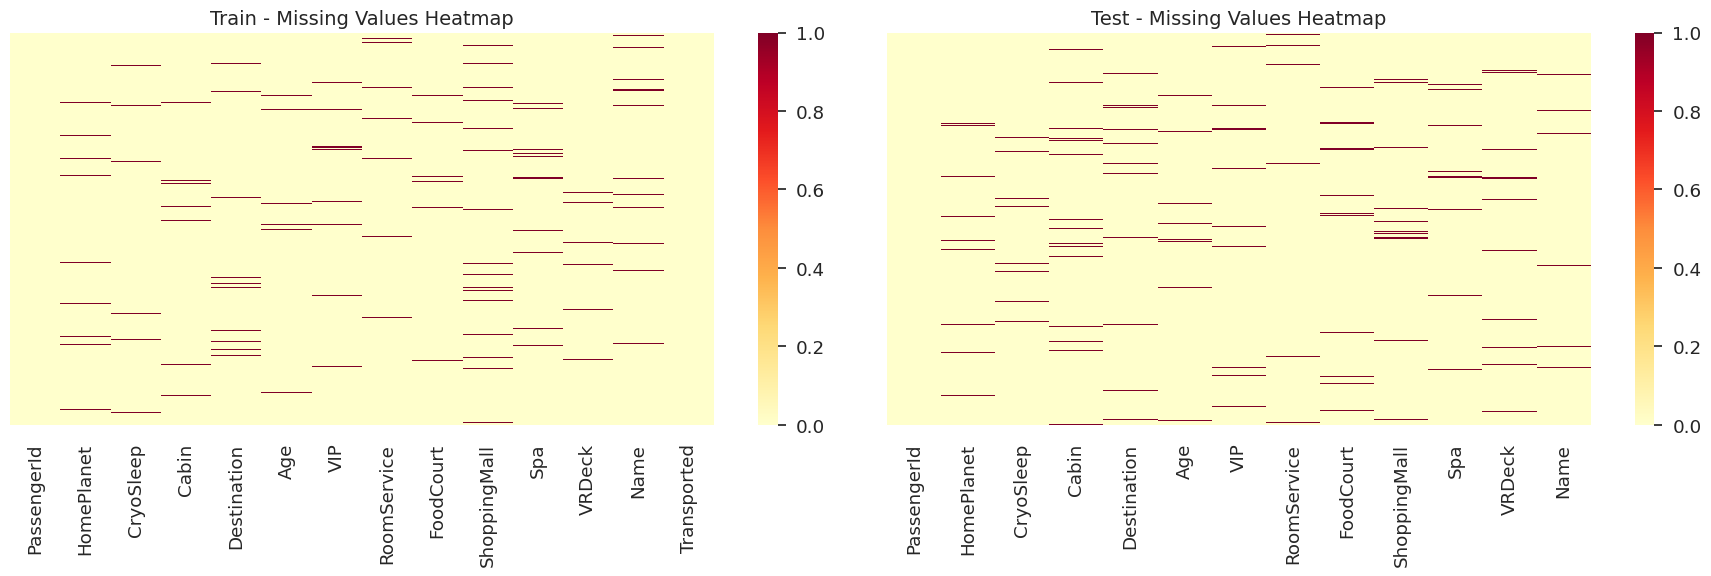

In [56]:
#  결측치 시각화 
# 히트맵으로 결측치의 분포 패턴을 확인
# 흰색 부분이 결측치

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(train.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Train - Missing Values Heatmap', fontsize=14)

sns.heatmap(test.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Test - Missing Values Heatmap', fontsize=14)

plt.tight_layout()
plt.show()





### 
결측치가 특정 행에 몰려있지 않고 랜덤하게 분포  
이는 MCAR(Missing Completely At Random)으로 판단할 수 있음   
결측치가 발생한 이유가 다른 데이터의 값이나, 결측된 그 값 자체와 아무런 상관이 없는 상태   
따라서 결측치를 적절한 값으로 대체(imputation)하는 것이 합리적

## 3. EDA (탐색적 테이터 분석)

### 각 feature를 하나씩 분석. 핵심은 " 이 변수가 transported(이송여부)와 어떤 관계가 있는가?를 파악하는것
1. 분포를 확인
2. Transported와의 관계를 시각화
3. 인사이트를 정리

## 3.1 Target변수 - Transported

Transported 분포:
Transported
True     4378
False    4315
Name: count, dtype: int64

Ratio: True=0.504, False=0.496


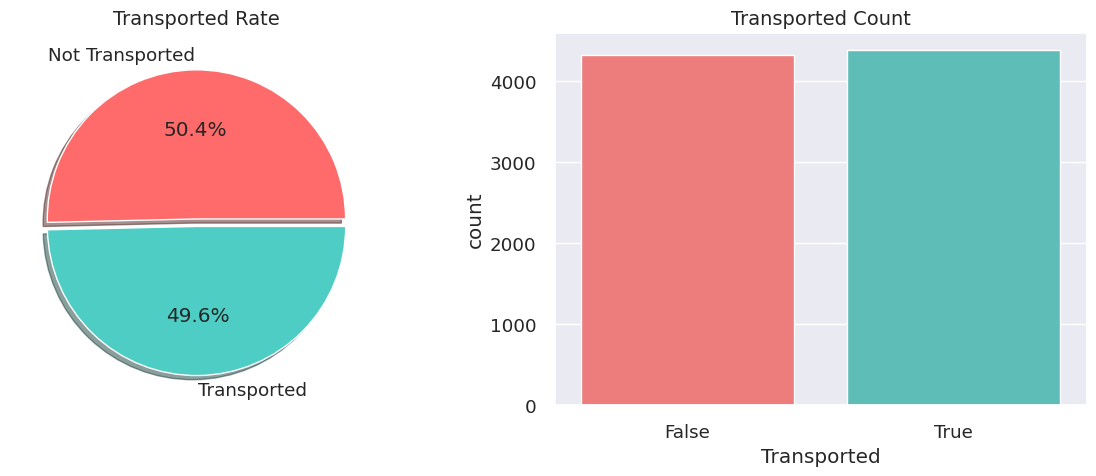

In [57]:
#  타겟 변수 분포 확인 
# Transported (True/False)
# 먼저 얼마나 균형잡혀 있는지 확인
# → 불균형하면 오버샘플링 등이 필요하지만, 균형잡혀 있으면 별도 처리 불필요

print("Transported 분포:")
print(train['Transported'].value_counts())
print(f"\nRatio: True={train['Transported'].mean():.3f}, False={1-train['Transported'].mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 파이차트
labels = ['Not Transported', 'Transported']
train['Transported'].value_counts().plot.pie(
    explode=[0, 0.05], shadow=True, autopct='%1.1f%%', 
    labels=labels, ax=axes[0], colors=['#FF6B6B', '#4ECDC4']
)
axes[0].set_title('Transported Rate', fontsize=14)
axes[0].set_ylabel('')

# 카운트 플롯
sns.countplot(x='Transported', data=train, ax=axes[1], palette=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Transported Count', fontsize=14)

plt.tight_layout()
plt.show()




###
True(이송됨)와 False(이송 안됨)가 약 50:50으로 매우 균형잡힌 데이터  
별도의 오버샘플링/언더샘플링이 필요하지 않음  
정확도(accuracy)를 평가 지표로 사용해도 문제없음


## 3.2 HomePlanet (출발행성)

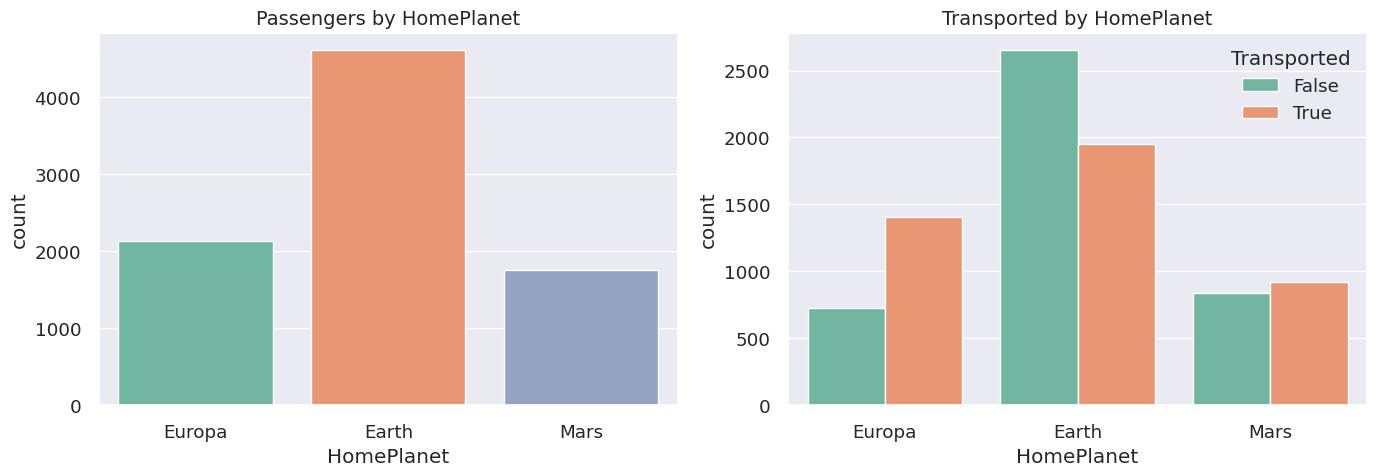


출발 행성별 Transported Ratio:
            Transported
HomePlanet             
Earth             0.424
Europa            0.659
Mars              0.523


In [58]:
#  HomePlanet 분석 
# 승객의 출발 행성이 Earth, Europa, Mars 중 어디인지를 나타냄
# "출발 행성에 따라 이송 확률이 달라질까?"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 행성별 탑승자 수
axes[0].set_title("Passengers by HomePlanet", fontsize=14)
sns.countplot(x='HomePlanet', data=train, ax=axes[0], palette='Set2')

# 오른쪽: 행성별 Transported Ratio
axes[1].set_title("Transported by HomePlanet", fontsize=14)
sns.countplot(x='HomePlanet', hue='Transported', data=train, ax=axes[1], palette='Set2')

plt.tight_layout()
plt.show()

# 행성별 이송 Ratio을 수치로 확인
print("\n출발 행성별 Transported Ratio:")
print(train[['HomePlanet', 'Transported']].groupby('HomePlanet').mean().round(3))


###

- **Earth** 출신이 가장 많지만, Transported 비율은 가장 **낮음** (~40%)
- **Europa** 출신은 Transported 비율이 가장 **높음** (~65%)
- **Mars** 출신은 중간 수준

출발 행성은 이송 여부에 유의미한 영향을 미침. 왜일까?  
추측: Europa 출신 승객이 CryoSleep을 많이 이용하거나, 특정 데크에 많이 배치되었을 가능성  
뒤에서 CryoSleep과 교차 분석으로 확인해보겠습니다.


## 3.3 CryoSleep(냉동수면)

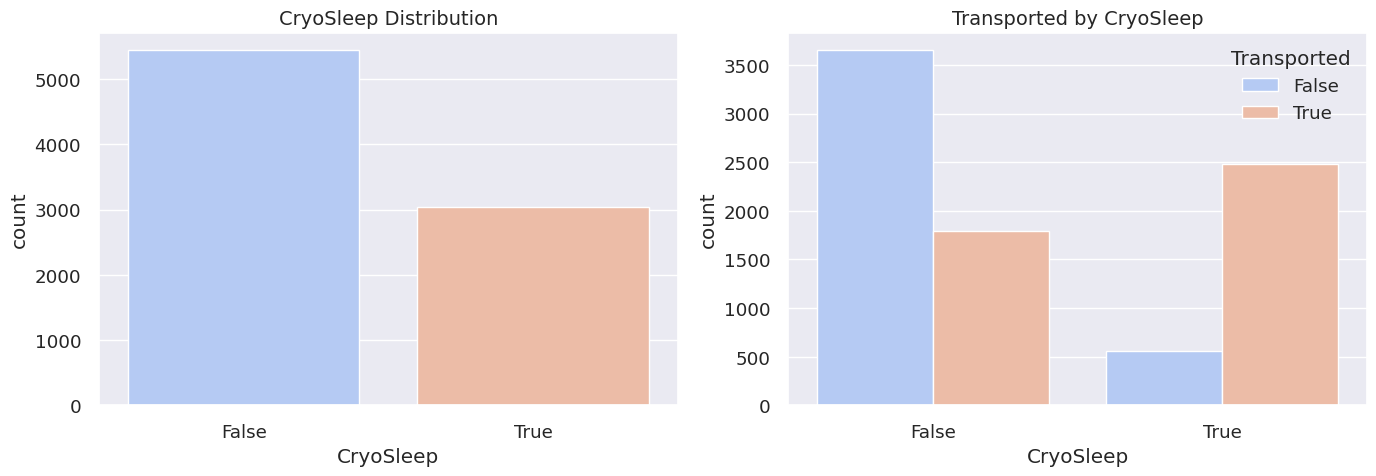


Transported by CryoSleep:
           Transported
CryoSleep             
False            0.329
True             0.818


In [60]:
# CryoSleep 분석 
# CryoSleep = True: 항해 중 냉동 캡슐에서 잠들어 있음
# 냉동 수면 중에는 선내 시설(RoomService, FoodCourt 등)을 이용할 수 없음
# 따라서 CryoSleep=True 이면 지출이 0이어야 함 (이걸 나중에 결측치 처리에 활용!)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title("CryoSleep Distribution", fontsize=14)
sns.countplot(x='CryoSleep', data=train, ax=axes[0], palette='coolwarm')

axes[1].set_title("Transported by CryoSleep", fontsize=14)
sns.countplot(x='CryoSleep', hue='Transported', data=train, ax=axes[1], palette='coolwarm')

plt.tight_layout()
plt.show()

print("\nTransported by CryoSleep:")
print(train[['CryoSleep', 'Transported']].groupby('CryoSleep').mean().round(3))

###
냉동 수면(CryoSleep=True) 승객의 Transported 비율이 약 80% 로 매우 높음!
- 반대로 냉동 수면을 하지 않은 승객은 약 30%만 이송됨
- CryoSleep은 Transported의 가장 강력한 예측 변수

  해석: 냉동 수면 중인 승객은 의식이 없어 시공간 이상 현상에 대응할 수 없었을 것.
  반면 깨어있는 승객은 대피하거나 대응할 수 있었을 가능성이 높음.

In [63]:
# CryoSleep과 지출의 관계 검증 
# CryoSleep=True 이면 정말로 지출이 0인지 확인
# 이 관계가 확인되면, 나중에 결측치 처리에 활용할 수 있음

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

cryo_true = train[train['CryoSleep'] == True]
cryo_false = train[train['CryoSleep'] == False]

print("=== CryoSleep=True 승객의 지출 합계 ===")
print(f"평균 총 지출: {cryo_true[spend_cols].sum(axis=1).mean():.2f}")
print(f"최대 총 지출: {cryo_true[spend_cols].sum(axis=1).max():.2f}")

print("\n=== CryoSleep=False 승객의 지출 합계 ===")
print(f"평균 총 지출: {cryo_false[spend_cols].sum(axis=1).mean():.2f}")
print(f"최대 총 지출: {cryo_false[spend_cols].sum(axis=1).max():.2f}")




=== CryoSleep=True 승객의 지출 합계 ===
평균 총 지출: 0.00
최대 총 지출: 0.00

=== CryoSleep=False 승객의 지출 합계 ===
평균 총 지출: 2248.30
최대 총 지출: 35987.00


###
 CryoSleep=True 이면 지출이 사실상 0  
 이 관계를 결측치 처리에 활용:
 "지출이 모두 0인데 CryoSleep이 결측 → CryoSleep=True로 추정"  
 "CryoSleep=True인데 지출이 결측 → 0으로 채움"


## 3.4 Destination (목적지)

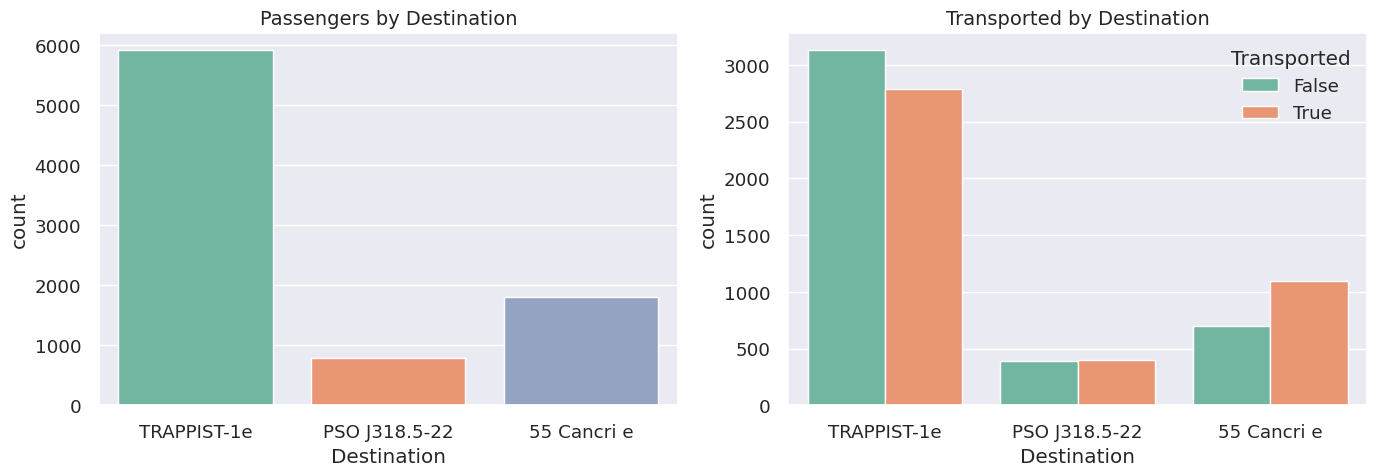


목적지별 Transported Ratio:
               Transported
Destination               
55 Cancri e          0.610
PSO J318.5-22        0.504
TRAPPIST-1e          0.471


In [66]:
# Destination 분석 
# 승객의 목적지 행성

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title("Passengers by Destination", fontsize=14)
sns.countplot(x='Destination', data=train, ax=axes[0], palette='Set2')

axes[1].set_title("Transported by Destination", fontsize=14)
sns.countplot(x='Destination', hue='Transported', data=train, ax=axes[1], palette='Set2')

plt.tight_layout()
plt.show()

print("\n목적지별 Transported Ratio:")
print(train[['Destination', 'Transported']].groupby('Destination').mean().round(3))




###
TRAPPIST-1e 가 가장 많은 승객의 목적지  
55 Cancri e 목적지 승객의 Transported Ratio이 가장 높음 (~60%)  
PSO J318.5-22 도 비교적 높은 편  
목적지에 따라 이송 확률에 약간의 차이가 있음


## 3.5 Age(나이)

Age Statistics:
count    8514.000000
mean       28.827930
std        14.489021
min         0.000000
25%        19.000000
50%        27.000000
75%        38.000000
max        79.000000
Name: Age, dtype: float64


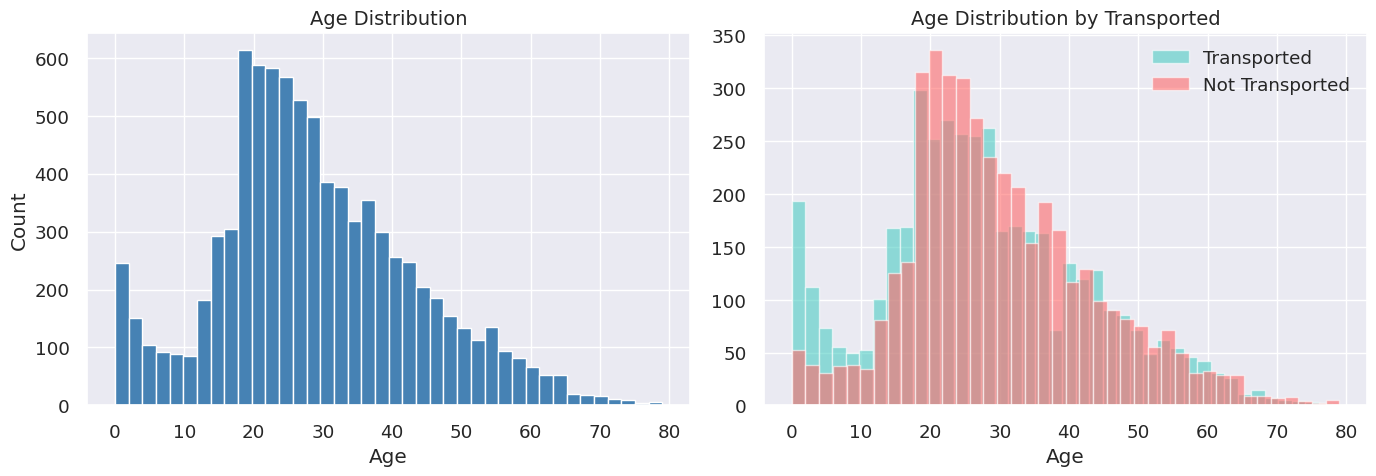

In [69]:
# Age 분석 
# 나이의 분포를 확인

print("Age Statistics:")
print(train['Age'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 전체 Age Distribution
axes[0].set_title("Age Distribution", fontsize=14)
train['Age'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# 오른쪽: Age Distribution by Transported 비교
axes[1].set_title("Age Distribution by Transported", fontsize=14)
train[train['Transported']==True]['Age'].hist(
    bins=40, alpha=0.6, label='Transported', color='#4ECDC4', ax=axes[1]
)
train[train['Transported']==False]['Age'].hist(
    bins=40, alpha=0.6, label='Not Transported', color='#FF6B6B', ax=axes[1]
)
axes[1].legend()
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()



###
승객 나이는 0 ~ 80세에 분포, 평균 약 29세  
0 ~ 12세(어린이)의 Transported Ratio이 상대적으로 높아 보임  
20 ~ 30대에서는 Not Transported가 상대적으로 많음

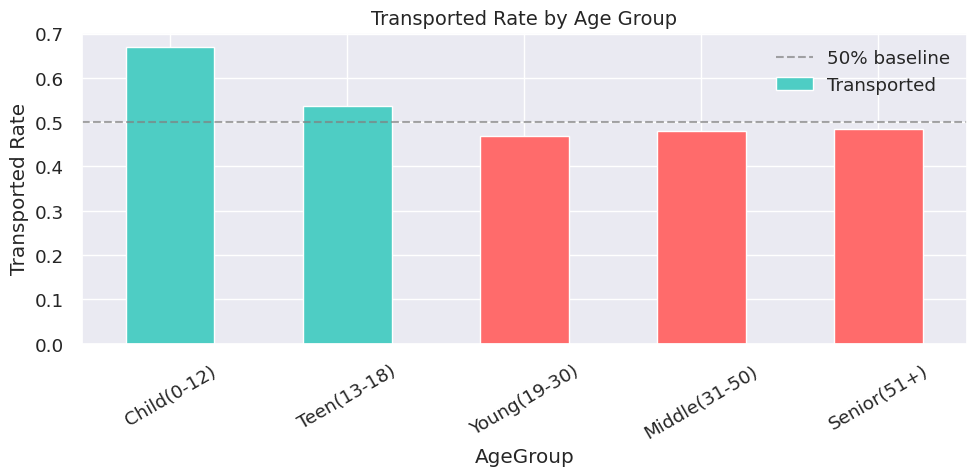

Transported Rate by Age Group:
AgeGroup
Child(0-12)      0.669
Teen(13-18)      0.537
Young(19-30)     0.468
Middle(31-50)    0.479
Senior(51+)      0.484
Name: Transported, dtype: float64


In [72]:
# 연령대를 나눠서 Transported Ratio을 정확하게 확인 
# 왜 연령대를 나눌까?
# 나이를 그대로 쓰면 패턴을 파악하기 어려움
# 구간으로 나누면 "어린이는 이송 Ratio이 높다" 같은 명확한 패턴을 확인할 수 있음

train['AgeGroup'] = pd.cut(train['Age'], bins=[0, 12, 18, 30, 50, 80],
                            labels=['Child(0-12)', 'Teen(13-18)', 'Young(19-30)',
                                    'Middle(31-50)', 'Senior(51+)'])

fig, ax = plt.subplots(figsize=(10, 5))
age_rate = train.groupby('AgeGroup')['Transported'].mean()
age_rate.plot(kind='bar', ax=ax, 
              color=['#4ECDC4' if v > 0.5 else '#FF6B6B' for v in age_rate])
ax.set_title('Transported Rate by Age Group', fontsize=14)
ax.set_ylabel('Transported Rate')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='50% baseline')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Transported Rate by Age Group:")
print(age_rate.round(3))

# 임시 컬럼 삭제
train.drop('AgeGroup', axis=1, inplace=True)




###
Child(0-12): 이송 Ratio이 가장 높음! (~65%+)  
Senior(51+): 두 번째로 높음  
Young(19-30): 이송 Ratio이 가장 낮음  
어린이는 부모가 냉동 수면시킨 경우가 많을 수 있음 → CryoSleep과 연관  
Feature Engineering 시 '어린이 여부(IsChild)' 를 만드는 것이 유효할 것

## 3.6 Cabin (객실)

In [91]:
#  Cabin 분석 
# Cabin은 "deck/num/side" 형식입니다
# 예: B/0/P → B데크, 0번방, P(좌현, Port side)
# 
# 이 컬럼을 통째로 쓰기보다 3개로 분리하면 유용한 정보를 얻을 수 있음
# - Cabin_deck: 데크 위치 (B, C, D, E, F, G, T 등)
# - Cabin_num: 방 번호
# - Cabin_side: 좌현(P) / 우현(S)

# Cabin을 분리
train[['Cabin_deck', 'Cabin_num', 'Cabin_side']] = train['Cabin'].str.split('/', expand=True)

print("Cabin_deck 고유값:", train['Cabin_deck'].unique())
print("Cabin_side 고유값:", train['Cabin_side'].unique())


Cabin_deck 고유값: ['B' 'F' 'A' 'G' nan 'E' 'D' 'C' 'T']
Cabin_side 고유값: ['P' 'S' nan]


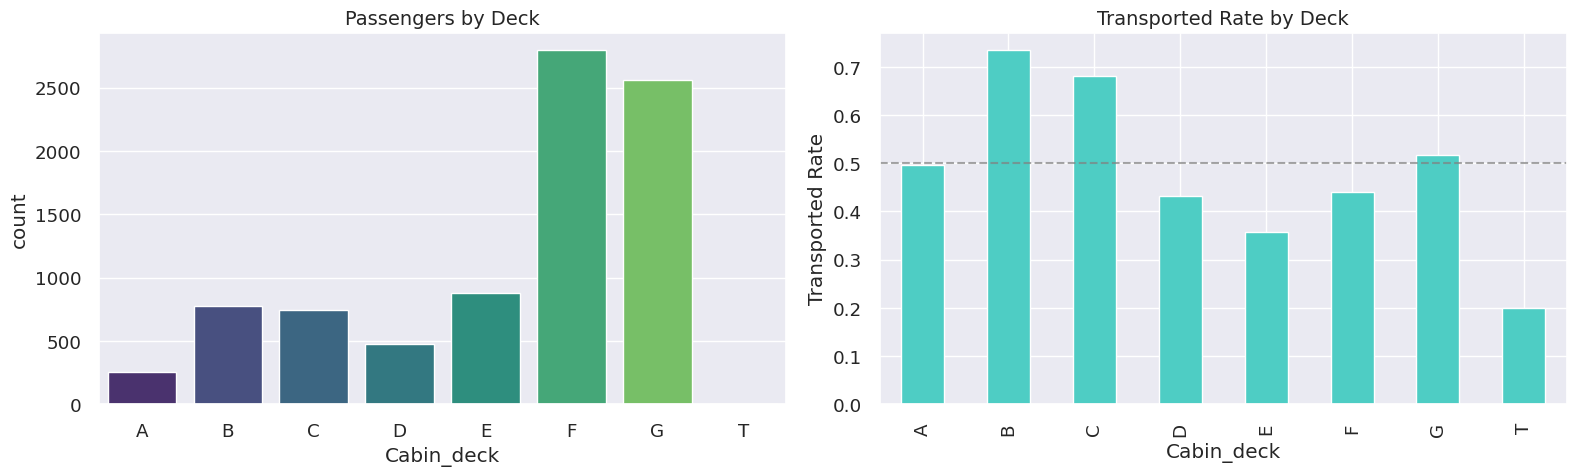

Transported Rate by Deck:
Cabin_deck
A    0.496
B    0.734
C    0.680
D    0.433
E    0.357
F    0.440
G    0.516
T    0.200
Name: Transported, dtype: float64


In [92]:
# Cabin_deck 별 Transported Ratio 
# 데크 위치에 따라 시공간 이상 현상의 영향이 달랐을 수 있음

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].set_title("Passengers by Deck", fontsize=14)
order = sorted(train['Cabin_deck'].dropna().unique())
sns.countplot(x='Cabin_deck', data=train, ax=axes[0], order=order, palette='viridis')

axes[1].set_title("Transported Rate by Deck", fontsize=14)
deck_rate = train.groupby('Cabin_deck')['Transported'].mean().reindex(order)
deck_rate.plot(kind='bar', ax=axes[1], color='#4ECDC4')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
axes[1].set_ylabel('Transported Rate')

plt.tight_layout()
plt.show()

print("Transported Rate by Deck:")
print(deck_rate.round(3))



###
B데크와 C데크의 Transported Ratio이 높음 (~60%+)  
F데크와 G데크는 상대적으로 낮음  
T데크는 샘플이 매우 적어 신뢰도가 낮음  
데크 위치가 이송 여부에 영향을 줌 = 우주선 내 물리적 위치가 중요

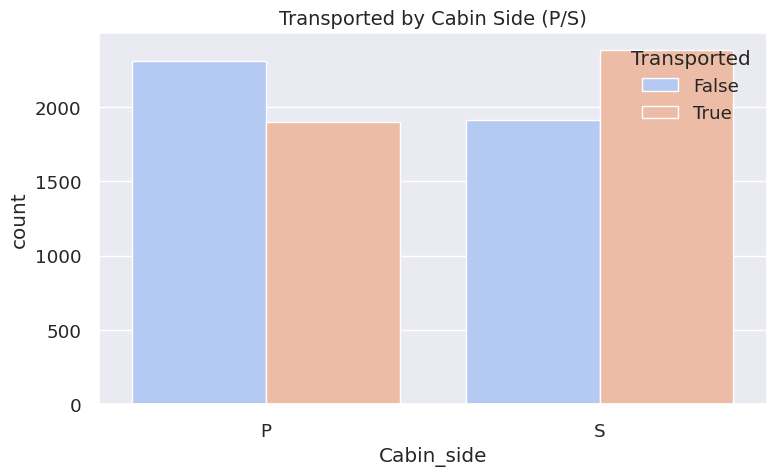

Side별 Transported Ratio:
Cabin_side
P    0.451
S    0.555
Name: Transported, dtype: float64


In [93]:
#  Cabin_side (좌현/우현) 별 Transported Ratio 
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(x='Cabin_side', hue='Transported', data=train, ax=ax, palette='coolwarm')
ax.set_title("Transported by Cabin Side (P/S)", fontsize=14)
plt.tight_layout()
plt.show()

print("Side별 Transported Ratio:")
print(train.groupby('Cabin_side')['Transported'].mean().round(3))




# 분석용 임시 컬럼 삭제 (나중에 전처리 단계에서 다시 만듦)
train.drop(['Cabin_deck', 'Cabin_num', 'Cabin_side'], axis=1, inplace=True)

###
S(우현, Starboard)쪽이 P(좌현, Port)보다 Transported Ratio이 약간 높음  
시공간 이상 현상이 우주선의 한쪽에 더 강하게 영향을 줬을 가능성이 있을거 같음

## 3.7 VIP

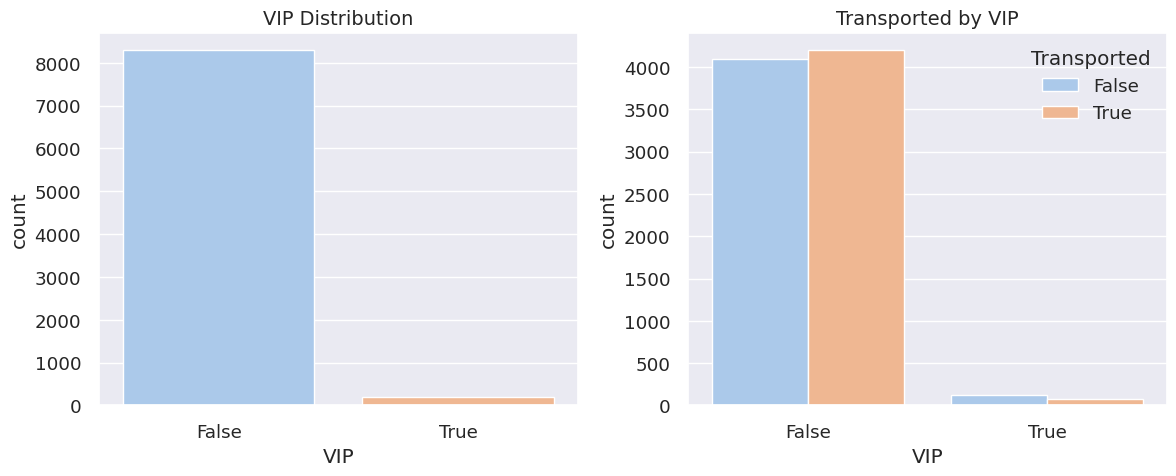

Transported by VIP Ratio:
       Transported
VIP               
False        0.506
True         0.382


In [94]:
#  VIP 분석 
# VIP 서비스를 이용한 승객과 아닌 승객의 Transported Ratio 차이를 확인

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("VIP Distribution", fontsize=14)
sns.countplot(x='VIP', data=train, ax=axes[0], palette='pastel')

axes[1].set_title("Transported by VIP", fontsize=14)
sns.countplot(x='VIP', hue='Transported', data=train, ax=axes[1], palette='pastel')

plt.tight_layout()
plt.show()

print("Transported by VIP Ratio:")
print(train[['VIP', 'Transported']].groupby('VIP').mean().round(3))

###
VIP 승객은 전체의 약 2%로 매우 소수  
VIP=True 승객의 Transported Ratio이 오히려 낮음 (~38%)  
VIP=False 승객은 ~50%  
VIP가 아닌 것이 오히려 이송될 확률이 높음
VIP 승객은 특별 구역에 있었거나, 비냉동 수면 상태일 가능성?

## 3.8 지출변수 (RoomService, FoodCourt, ShoppingMall, Spa, Vrdesk)

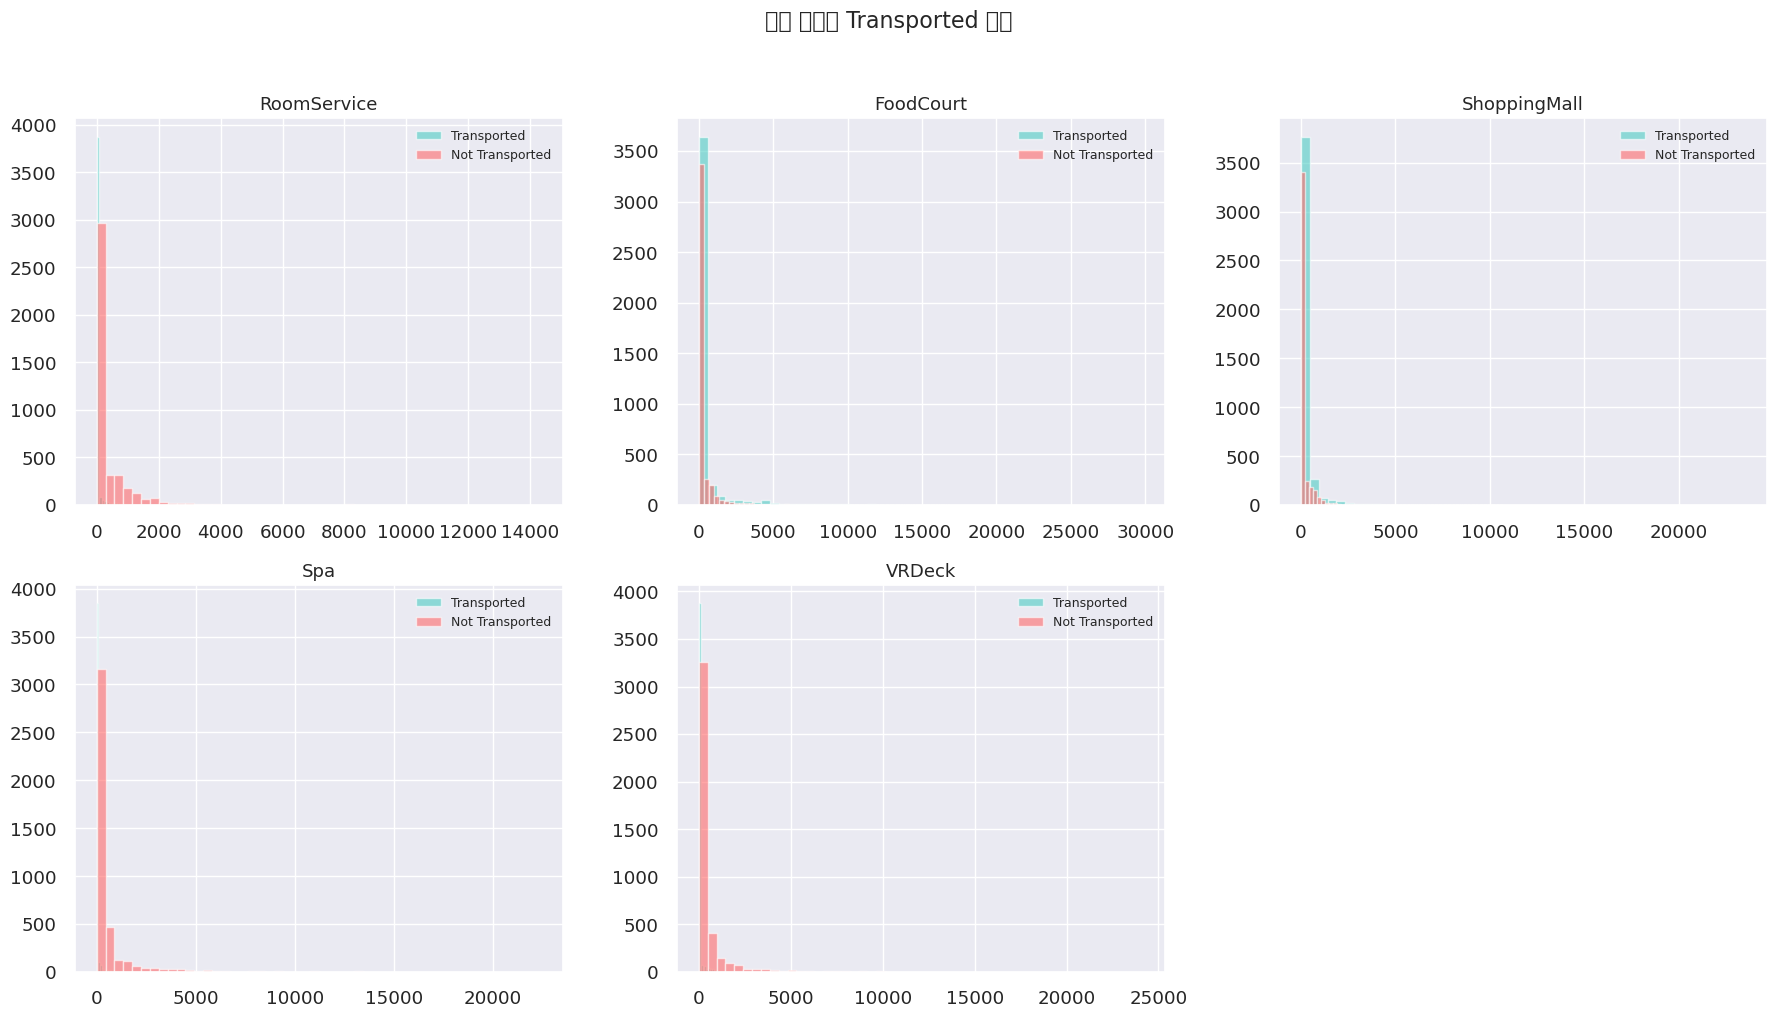

In [96]:
# 5개 지출 변수의 분포 확인 
# 이 5개 변수는 모두 "선내 럭셔리 시설 이용 비용"
# 앞서 CryoSleep=True이면 지출=0 인 것을 확인함
# 지출이 클수록 활동적인 승객 → Transported 확률이 낮을 것으로 예상

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(spend_cols):
    ax = axes[i]
   
    train[train['Transported']==True][col].hist(
        bins=50, alpha=0.6, label='Transported', color='#4ECDC4', ax=ax
    )
    train[train['Transported']==False][col].hist(
        bins=50, alpha=0.6, label='Not Transported', color='#FF6B6B', ax=ax
    )
    ax.set_title(f'{col}', fontsize=13)
    ax.legend(fontsize=9)


axes[5].axis('off')
plt.suptitle('지출 변수별 Transported 비교', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

###
모든 지출 변수가 0에 극도로 집중된 Right-skewed 분포  
대부분의 승객이 지출 0 (냉동 수면이거나 시설 미이용)  
지출이 0인 그룹에서 Transported Ratio이 높음  
지출이 높은 승객일수록 Transported Ratio 낮음  
"지출 총합"이나 "지출 여부(0인지 아닌지)"를 Feature로 만들면 유효할 것

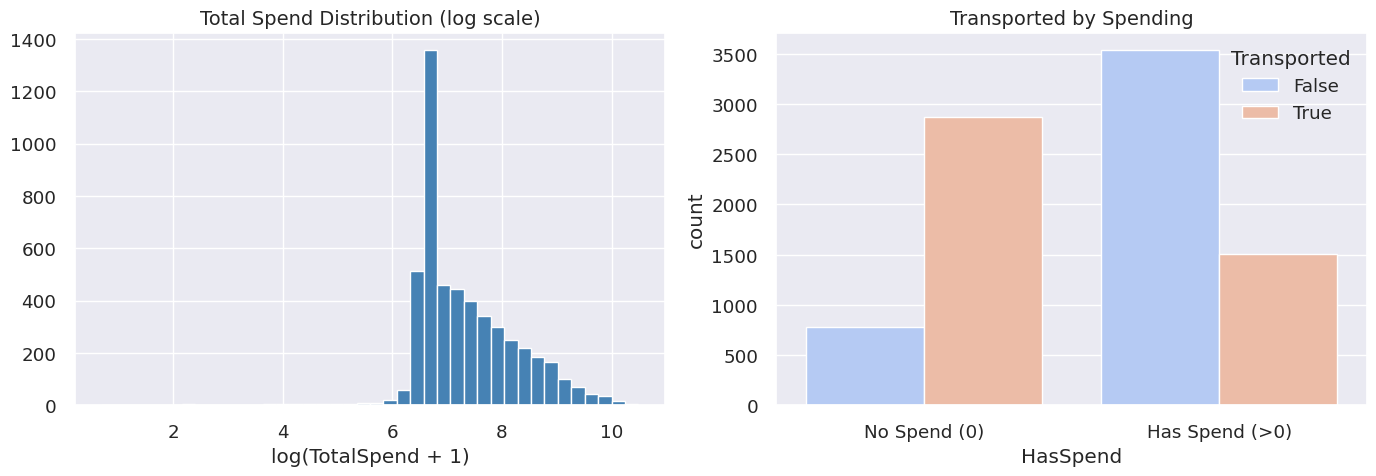

Transported by Spending Ratio:
HasSpend
0    0.786
1    0.299
Name: Transported, dtype: float64


In [98]:
#  총 지출액 vs Transported 
# 지출 변수 5개를 합산한 TotalSpend 를 만들어서 패턴을 확인

train['TotalSpend'] = train[spend_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 총 지출 분포 (log 스케일 — 값이 크게 치우쳐 있으므로)
axes[0].set_title("Total Spend Distribution (log scale)", fontsize=14)
train[train['TotalSpend'] > 0]['TotalSpend'].apply(np.log1p).hist(
    bins=40, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_xlabel('log(TotalSpend + 1)')

# 오른쪽: 지출 여부(0원 vs 0원 초과)별 Transported Ratio
train['HasSpend'] = (train['TotalSpend'] > 0).astype(int)
axes[1].set_title("Transported by Spending", fontsize=14)
sns.countplot(x='HasSpend', hue='Transported', data=train, ax=axes[1], palette='coolwarm')
axes[1].set_xticklabels(['No Spend (0)', 'Has Spend (>0)'])

plt.tight_layout()
plt.show()

print("Transported by Spending Ratio:")
print(train.groupby('HasSpend')['Transported'].mean().round(3))

# 임시 컬럼 삭제
train.drop(['TotalSpend', 'HasSpend'], axis=1, inplace=True)

###
지출 없음(=0): Transported Ratio ~70%! 매우 높음  
지출 있음(>0): Transported Ratio ~30%    
"지출 여부"는 CryoSleep만큼 강력한 예측 변수!  
이유: 지출=0 ≈ 냉동 수면 → Transported 확률 높음


## 3.9 상관관계 분석

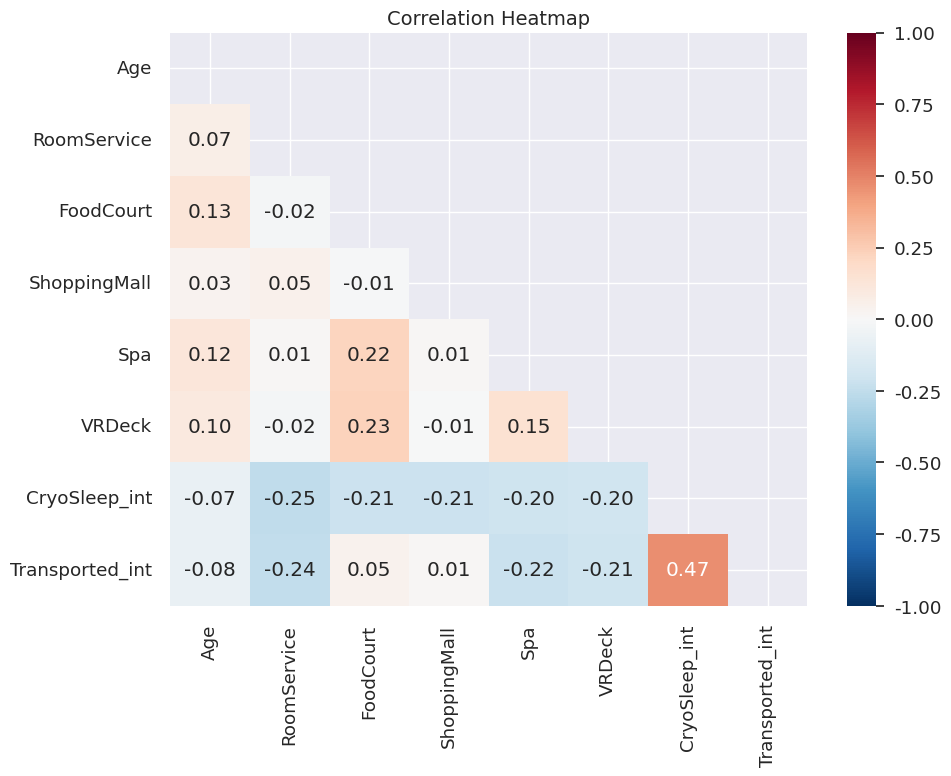

In [100]:
# 수치형 변수 간의 상관관계 
# 어떤 변수들이 서로 관련이 있는지, Target과 어떤 관계인지 확인

corr_data = train.copy()
corr_data['Transported_int'] = corr_data['Transported'].astype(int)
corr_data['CryoSleep_int'] = corr_data['CryoSleep'].astype(float)

num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
            'CryoSleep_int', 'Transported_int']

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = corr_data[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

###
CryoSleep과 Transported: 강한 양의 상관관계 (~0.46) → 핵심 변수 확인  
지출 변수들과 Transported: 음의 상관관계 → 돈 쓸수록 이송 안됨  
지출 변수들끼리도 약한 양의 상관관계 → 활발한 승객은 여러 시설 이용  
RoomService, Spa: 서로 양의 상관 → 비슷한 성격의 시설


## 3.10 HomePlanet x CryoSleep 교차 분석

행성별 CryoSleep Ratio:
CryoSleep   False  True 
HomePlanet              
Earth       0.692  0.308
Europa      0.561  0.439
Mars        0.610  0.390


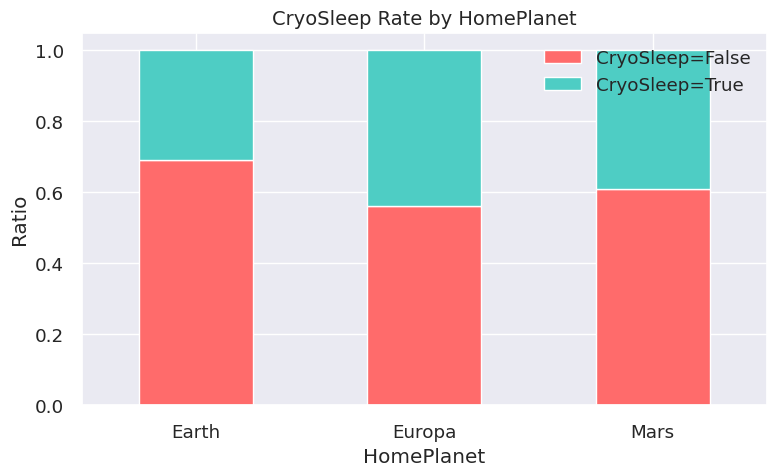

In [101]:
# HomePlanet과 CryoSleep의 교차 분석 
# 앞서 "Europa 출신의 Transported Ratio이 높다"는 것을 발견
# 혹시 Europa 출신이 CryoSleep을 많이 해서 그런 건 아닐까? 확인

ct = pd.crosstab(train['HomePlanet'], train['CryoSleep'], normalize='index')
print("행성별 CryoSleep Ratio:")
print(ct.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ct.plot(kind='bar', stacked=True, ax=ax, color=['#FF6B6B', '#4ECDC4'])
ax.set_title('CryoSleep Rate by HomePlanet', fontsize=14)
ax.set_ylabel('Ratio')
ax.legend(['CryoSleep=False', 'CryoSleep=True'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###
Europa 출신의 CryoSleep Ratio이 Earth나 Mars보다 높음!  
이것이 Europa 출신의 높은 Transported Ratio을 설명하는 핵심 요인  
즉, HomePlanet → CryoSleep → Transported 의 인과 경로가 있을 수 있음

## EDA 종합 정리

| 발견 | 의미 | 활용 |
|------|------|------|
| CryoSleep=True → Transported 80% | 가장 강력한 예측 변수 | 결측치 처리 + 핵심 feature |
| 지출=0 → Transported 70% | CryoSleep과 연동되는 강력한 신호 | TotalSpend, NoSpend feature 생성 |
| Europa 출신 → Transported 높음 | CryoSleep 비율이 높아서 | HomePlanet feature 유지 |
| 어린이(0-12) → Transported 높음 | 부모와 함께 냉동 수면? | IsChild feature 생성 |
| B,C 데크 → Transported 높음 | 물리적 위치 영향 | Cabin_deck feature 사용 |
| S(우현) → 약간 높음 | 시공간 이상 방향성 | Cabin_side feature 사용 |

## 4. 결측치 처리

### EDA에서 얻은 인사이트를 바탕으로 결측치를 채운다. 단순히 평균/최빈값으로 채우는 것이 아니라, 데이터의 관계를 이용


### 결측치 처리 전략

| 컬럼 | 방법 | 근거 |
|------|------|------|
| CryoSleep | 지출 총합=0이면 True, >0이면 False | EDA에서 확인: 냉동수면 시 지출 불가 |
| 지출 5개 | CryoSleep=True → 0, False → 중앙값 | 냉동수면 중 지출 불가, 비냉동은 약간의 지출 |
| HomePlanet | 같은 그룹 값 → 최빈값 | 같은 그룹 = 가족/동행 → 같은 행성 출발 |
| Destination | 같은 그룹 값 → 최빈값 | 동일 논리 |
| Cabin | 같은 그룹 값 → 최빈값 | 가족은 인접 객실 배정 가능성 높음 |
| Age | HomePlanet별 중앙값 | 행성마다 연령 분포가 다를 수 있음 |
| VIP | False로 채움 | VIP 비율이 ~2%로 극소수 |
| Name | 결측 유지 | 모델에 직접 사용하지 않음 |

In [293]:
# # 전처리를 위해 train과 test를 합친다
# # 왜 합칠까?
# # → train과 test에 동일한 전처리를 적용해야 하므로
# # → 합쳐서 한번에 처리하면 코드가 깔끔하고, 일관성이 보장됨
# # → 나중에 다시 분리

# all_data = pd.concat([train, test], ignore_index=True)
# print(f"합친 데이터 크기: {all_data.shape}")
# print(f"Train: {len(train)}행, Test: {len(test)}행, 합계: {len(all_data)}행")

In [294]:
# #  PassengerId에서 그룹 정보 추출 
# # PassengerId 형식: "0001_01" → 그룹번호_그룹내번호
# # 같은 그룹 = 함께 여행하는 가족/동행
# # → 결측치를 같은 그룹의 다른 멤버 값으로 채울 수 있음

# all_data['Group'] = all_data['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
# all_data['PersonNum'] = all_data['PassengerId'].apply(lambda x: x.split('_')[1]).astype(int)

# # 그룹 크기 확인
# group_counts = all_data['Group'].value_counts()
# print(f"전체 그룹 수: {group_counts.shape[0]}")
# print(f"1인 그룹 (혼자 여행): {(group_counts == 1).sum()}")
# print(f"2인 이상 그룹: {(group_counts >= 2).sum()}")


In [295]:
# #  Cabin 분리 
# # "B/0/P" → Cabin_deck="B", Cabin_num=0, Cabin_side="P"
# # 왜 분리할까?
# # → Cabin 자체는 고유값이 너무 많아 모델에 직접 넣기 어려움
# # → deck, side는 범주형으로, num은 수치형으로 각각 활용 가능

# all_data[['Cabin_deck', 'Cabin_num', 'Cabin_side']] = \
#     all_data['Cabin'].str.split('/', expand=True)
# all_data['Cabin_num'] = pd.to_numeric(all_data['Cabin_num'], errors='coerce')

# print("Cabin 분리 완료")
# print(f"Cabin_deck 고유값: {all_data['Cabin_deck'].dropna().unique()}")
# print(f"Cabin_side 고유값: {all_data['Cabin_side'].dropna().unique()}")

In [288]:
# #  4.1 CryoSleep 결측 처리 
# # 근거: EDA에서 확인한 "CryoSleep=True ↔ 지출=0" 관계를 역으로 이용
# # 지출 5개가 모두 0(또는 NaN) → 냉동 수면 중이었을 가능성 높음 → True
# # 지출 중 하나라도 > 0 → 깨어있었음 → False

# spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# mask_null = all_data['CryoSleep'].isnull()
# total_spend = all_data.loc[mask_null, spend_cols].fillna(0).sum(axis=1)

# all_data.loc[mask_null & (total_spend == 0), 'CryoSleep'] = True
# all_data.loc[mask_null & (total_spend > 0), 'CryoSleep'] = False

# # 그래도 남는 결측치 → 최빈값
# all_data['CryoSleep'].fillna(all_data['CryoSleep'].mode()[0], inplace=True)

# print(f"CryoSleep 결측 처리 완료. 남은 결측: {all_data['CryoSleep'].isnull().sum()}")


In [296]:
# # 지출 컬럼 리스트
# exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# # (1) 돈을 한 푼이라도 썼다면, 냉동수면(CryoSleep)은 무조건 False입니다.
# all_data.loc[(all_data['CryoSleep'].isnull()) & (all_data[exp_cols].sum(axis=1) > 0), 'CryoSleep'] = False

# # (2) 반대로 냉동수면(CryoSleep)이 True인 사람의 지출 결측치는 모두 0으로 채웁니다.
# for col in exp_cols:
#     all_data.loc[(all_data['CryoSleep'] == True) & (all_data[col].isnull()), col] = 0

In [297]:
# # === 4.1 CryoSleep 결측 처리 (개선) ===
# # [기존] 지출=0이면 True로만 판단
# # [개선] 추가 조건: 같은 그룹의 CryoSleep 값도 참고
# #   → 가족이 모두 냉동수면이면, 결측인 멤버도 냉동수면일 가능성 높음

# spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# # Step 1: 그룹 내 다른 멤버의 CryoSleep으로 먼저 채움
# def fill_by_group(df, col):
#     filled = 0
#     for group_id, group_df in df[df[col].isnull()].groupby('Group'):
#         known = df[(df['Group'] == group_id) & (df[col].notnull())][col]
#         if len(known) > 0:
#             fill_val = known.mode()[0]
#             df.loc[(df['Group'] == group_id) & (df[col].isnull()), col] = fill_val
#             filled += group_df[col].isnull().sum()
#     return filled

# n = fill_by_group(all_data, 'CryoSleep')
# print(f"CryoSleep: 그룹 기반으로 {n}개 복구")

# # Step 2: 남은 결측 → 지출 합계로 판단
# mask_null = all_data['CryoSleep'].isnull()
# total_spend = all_data.loc[mask_null, spend_cols].fillna(0).sum(axis=1)
# all_data.loc[mask_null & (total_spend == 0), 'CryoSleep'] = True
# all_data.loc[mask_null & (total_spend > 0), 'CryoSleep'] = False

# # Step 3: 그래도 남으면 최빈값
# all_data['CryoSleep'].fillna(all_data['CryoSleep'].mode()[0], inplace=True)
# print(f"CryoSleep 결측 남은 수: {all_data['CryoSleep'].isnull().sum()}")

In [291]:
# # 4.2 지출 5개 컬럼 결측 처리 
# # 근거:
# # - CryoSleep=True → 시설 이용 불가 → 지출은 반드시 0
# # - CryoSleep=False → 시설을 이용할 수 있으므로 → 해당 컬럼의 중앙값으로 채움
# #   (평균이 아닌 중앙값을 쓰는 이유: 지출 데이터가 극심한 Right-skew이므로 
# #    평균은 극단값에 영향을 받음. 중앙값이 더 대표적인 값)

# for col in spend_cols:
#     # CryoSleep=True 이면서 지출이 결측 → 0
#     all_data.loc[(all_data['CryoSleep'] == True) & (all_data[col].isnull()), col] = 0.0
    
#     # CryoSleep=False 이면서 지출이 결측 → 비냉동 승객의 중앙값
#     median_val = all_data.loc[all_data['CryoSleep'] == False, col].median()
#     all_data.loc[(all_data['CryoSleep'] == False) & (all_data[col].isnull()), col] = median_val

# print("지출 컬럼 결측 처리 완료:")
# for col in spend_cols:
#     print(f"  {col}: 결측 {all_data[col].isnull().sum()}")

In [298]:
# # === 4.2 지출 컬럼 결측 처리 (개선) ===
# # [기존] CryoSleep=False → 전체 중앙값
# # [개선] CryoSleep=False → HomePlanet별 중앙값
# #   → 행성마다 소비 패턴이 다름 (Europa는 럭셔리, Earth는 기본 시설 위주)

# for col in spend_cols:
#     # CryoSleep=True → 0
#     all_data.loc[(all_data['CryoSleep'] == True) & (all_data[col].isnull()), col] = 0.0
    
#     # CryoSleep=False → HomePlanet별 중앙값
#     for planet in all_data['HomePlanet'].dropna().unique():
#         median_val = all_data.loc[
#             (all_data['CryoSleep'] == False) & 
#             (all_data['HomePlanet'] == planet) & 
#             (all_data[col].notnull()), col
#         ].median()
        
#         mask = ((all_data['CryoSleep'] == False) & 
#                 (all_data['HomePlanet'] == planet) & 
#                 (all_data[col].isnull()))
#         all_data.loc[mask, col] = median_val
    
#     # 혹시 남은 결측 → 전체 중앙값
#     all_data[col].fillna(all_data[col].median(), inplace=True)

# print("지출 컬럼 결측 처리 완료:")
# print(all_data[spend_cols].isnull().sum())

In [243]:
# #  4.3 그룹 기반 결측 처리 (HomePlanet, Destination, Cabin) 
# # 근거: 같은 그룹은 가족/동행 → 같은 행성에서 출발, 같은 목적지로 향함
# # 같은 그룹의 다른 멤버에게 값이 있으면 그 값으로 채움

# def fill_by_group(df, col):
#     """같은 그룹 내 다른 멤버의 값으로 결측치 채우기"""
#     filled_count = 0
#     for group_id, group_df in df[df[col].isnull()].groupby('Group'):
#         # 같은 그룹에서 해당 컬럼에 값이 있는 멤버를 찾음
#         known = df[(df['Group'] == group_id) & (df[col].notnull())][col]
#         if len(known) > 0:
#             fill_val = known.mode()[0]  # 가장 흔한 값으로 채움
#             df.loc[(df['Group'] == group_id) & (df[col].isnull()), col] = fill_val
#             filled_count += group_df[col].isnull().sum()
#     return filled_count

# # HomePlanet, Destination
# for col in ['HomePlanet', 'Destination']:
#     before = all_data[col].isnull().sum()
#     n_filled = fill_by_group(all_data, col)
#     all_data[col].fillna(all_data[col].mode()[0], inplace=True)  # 나머지는 최빈값
#     after = all_data[col].isnull().sum()
#     print(f"{col}: 결측 {before} → {after} (그룹으로 {n_filled}개 복구, 나머지 최빈값)")

# # Cabin (deck, side)
# for sub_col in ['Cabin_deck', 'Cabin_side']:
#     before = all_data[sub_col].isnull().sum()
#     fill_by_group(all_data, sub_col)
#     all_data[sub_col].fillna(all_data[sub_col].mode()[0], inplace=True)
#     after = all_data[sub_col].isnull().sum()
#     print(f"{sub_col}: 결측 {before} → {after}")

# # Cabin_num → 중앙값
# all_data['Cabin_num'].fillna(all_data['Cabin_num'].median(), inplace=True)
# print(f"Cabin_num: 결측 → {all_data['Cabin_num'].isnull().sum()}")


In [299]:
# === 4.3 HomePlanet ↔ Cabin_deck 상호 보완 (개선) ===
# [기존] 그룹 → 최빈값
# [개선] HomePlanet과 Cabin_deck의 강한 관계를 활용
#   Europa → B, C 데크 / Earth → G, F 데크 / Mars → F, E 데크
#   이 관계를 양방향으로 활용하여 서로의 결측치를 채움

# # Step 1: 그룹 기반 (가족끼리 같은 행성/목적지)
# for col in ['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side']:
#     before = all_data[col].isnull().sum()
#     fill_by_group(all_data, col)
#     after = all_data[col].isnull().sum()
#     print(f"{col}: 그룹 기반 {before} → {after}")

# # Step 2: HomePlanet ↔ Cabin_deck 상호 보완
# # Cabin_deck → HomePlanet 매핑 (데이터에서 가장 흔한 조합)
# deck_to_planet = all_data.dropna(subset=['Cabin_deck', 'HomePlanet'])\
#     .groupby('Cabin_deck')['HomePlanet'].agg(lambda x: x.mode()[0])

# # HomePlanet이 결측인데 Cabin_deck가 있으면 → 매핑으로 채움
# mask = all_data['HomePlanet'].isnull() & all_data['Cabin_deck'].notnull()
# all_data.loc[mask, 'HomePlanet'] = all_data.loc[mask, 'Cabin_deck'].map(deck_to_planet)
# print(f"\nHomePlanet: deck→planet 매핑으로 추가 복구 → 남은 결측: {all_data['HomePlanet'].isnull().sum()}")

# # 반대: HomePlanet → Cabin_deck 매핑
# planet_to_deck = all_data.dropna(subset=['HomePlanet', 'Cabin_deck'])\
#     .groupby('HomePlanet')['Cabin_deck'].agg(lambda x: x.mode()[0])

# mask = all_data['Cabin_deck'].isnull() & all_data['HomePlanet'].notnull()
# all_data.loc[mask, 'Cabin_deck'] = all_data.loc[mask, 'HomePlanet'].map(planet_to_deck)
# print(f"Cabin_deck: planet→deck 매핑으로 추가 복구 → 남은 결측: {all_data['Cabin_deck'].isnull().sum()}")

# # Step 3: 나머지 최빈값
# for col in ['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side']:
#     all_data[col].fillna(all_data[col].mode()[0], inplace=True)

# all_data['Cabin_num'].fillna(all_data['Cabin_num'].median(), inplace=True)
print("\n나머지 최빈값/중앙값 처리 완료")


나머지 최빈값/중앙값 처리 완료


In [245]:
# #  4.4 Age 결측 처리 
# # 근거: HomePlanet에 따라 연령 분포가 다를 수 있음
# # → 전체 중앙값보다 HomePlanet별 중앙값이 더 정확한 대체값

# print("HomePlanet별 나이 중앙값:")
# print(all_data.groupby('HomePlanet')['Age'].median().round(1))

# all_data['Age'] = all_data.groupby('HomePlanet')['Age'].transform(
#     lambda x: x.fillna(x.median())
# )
# print(f"\nAge 결측 처리 완료. 남은 결측: {all_data['Age'].isnull().sum()}")


In [300]:
# # === 4.4 Age 결측 처리 (개선) ===
# # [기존] HomePlanet별 중앙값
# # [개선] HomePlanet + CryoSleep 조합별 중앙값
# #   → 냉동수면 여부에 따라 연령 분포가 다름
# #   → 더 정확한 대체값

# print("HomePlanet × CryoSleep별 나이 중앙값:")
# print(all_data.groupby(['HomePlanet', 'CryoSleep'])['Age'].median().round(1))

# all_data['Age'] = all_data.groupby(['HomePlanet', 'CryoSleep'])['Age'].transform(
#     lambda x: x.fillna(x.median())
# )

# # 혹시 남은 결측 → 전체 중앙값
# all_data['Age'].fillna(all_data['Age'].median(), inplace=True)
# print(f"\nAge 결측 남은 수: {all_data['Age'].isnull().sum()}")

In [247]:
# #  4.5 VIP 결측 처리 
# # 근거: VIP는 전체의 약 2%만 True
# # → 결측치를 False로 채우는 것이 가장 안전한 선택

# all_data['VIP'].fillna(False, inplace=True)
# print(f"VIP 결측 처리 완료. 남은 결측: {all_data['VIP'].isnull().sum()}")

In [301]:
# # === 4.5 VIP 결측 처리 (개선) ===
# # [기존] 무조건 False
# # [개선] HomePlanet별 최빈값으로 채움
# #   → Europa 출신은 VIP 비율이 상대적으로 높음

# print("HomePlanet별 VIP 비율:")
# print(all_data.groupby('HomePlanet')['VIP'].mean().round(3))

# all_data['VIP'] = all_data.groupby('HomePlanet')['VIP'].transform(
#     lambda x: x.fillna(x.mode()[0])
# )
# all_data['VIP'].fillna(False, inplace=True)
# print(f"VIP 결측 남은 수: {all_data['VIP'].isnull().sum()}")

In [302]:
# # === 4.6 최종 결측치 확인 ===
# model_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
#               'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
#               'Cabin_deck', 'Cabin_side', 'Cabin_num', 'Group']

# remaining = all_data[model_cols].isnull().sum()
# if remaining.sum() == 0:
#     print("✅ 모든 모델 사용 컬럼의 결측치 처리 완료! 결측치 없음!")
# else:
#     print(" 남은 결측치:")
#     print(remaining[remaining > 0])

In [326]:
# --- [지능형 결측치 처리 통합본] ---

# 1. 그룹 정보 생성 및 지출 변수 정의
all_data['Group'] = all_data['PassengerId'].apply(lambda x: x.split('_')[0])
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. [논리 추론] 돈 썼으면 냉동수면 X, 냉동수면 중이면 지출 0
all_data.loc[(all_data['CryoSleep'].isnull()) & (all_data[exp_cols].sum(axis=1) > 0), 'CryoSleep'] = False
for col in exp_cols:
    all_data.loc[(all_data['CryoSleep'] == True) & (all_data[col].isnull()), col] = 0

# 3. [그룹 기반 채우기] 가족/일행 정보를 이용해 행성, 목적지, 객실 채우기
for col in ['HomePlanet', 'Destination', 'Cabin']:
    all_data[col] = all_data.groupby('Group')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

# 4. [객실 정보 분리]
all_data[['Cabin_deck', 'Cabin_num', 'Cabin_side']] = all_data['Cabin'].str.split('/', expand=True)

# 5. [수치형 변수] 지출은 0으로, 나이는 행성별 중앙값으로
all_data[exp_cols] = all_data[exp_cols].fillna(0)
all_data['Age'] = all_data.groupby(['HomePlanet'])['Age'].transform(lambda x: x.fillna(x.median()))

# 6. [에러 방지] Cabin_num 숫자 변환 및 결측치 처리
all_data['Cabin_num'] = pd.to_numeric(all_data['Cabin_num'], errors='coerce')
all_data['Cabin_num'] = all_data['Cabin_num'].fillna(all_data['Cabin_num'].median())

# 7. [최종 마무리] 여전히 남은 것들은 전체 최빈값으로
final_cols = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP', 'Cabin_deck', 'Cabin_side']
for col in final_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print("✅ 결측치 처리 업그레이드 완료!")

✅ 결측치 처리 업그레이드 완료!


In [327]:
print(all_data['Cabin_num'].isnull().sum()) # 0이 나와야 합니다.


0


## 5. Feature Engineering <a id="5"></a>

EDA에서 발견한 인사이트를 바탕으로 새로운 feature를 만든다.
좋은 feature를 만드는 것이 모델 성능 향상에 가장 큰 기여를 한다.


In [328]:
#  5.1 총 지출액 (TotalSpend) 
# 왜 만들까?
# → EDA에서 "지출이 0이면 Transported Ratio이 70%"임을 확인
# → 5개 지출 변수를 합산하면 승객의 전반적인 활동 수준을 나타내는 강력한 feature
# → 개별 지출보다 총합이 더 직관적인 패턴을 보여줌

all_data['TotalSpend'] = all_data[spend_cols].sum(axis=1)
print(f"TotalSpend 생성 완료. 평균: {all_data['TotalSpend'].mean():.1f}")

TotalSpend 생성 완료. 평균: 1433.5


In [329]:
# 5.2 지출 여부 (NoSpend) 
# 왜 만들까?
# → 총 지출이 0인지 아닌지가 이진 신호로서 매우 강력함
# → CryoSleep과 높은 상관관계 (냉동 수면 → 지출 0)
# → 모델이 "지출 0" vs "지출 있음"을 쉽게 구분할 수 있게 해줌

all_data['NoSpend'] = (all_data['TotalSpend'] == 0).astype(int)
print(f"NoSpend=1 (지출 없음) Ratio: {all_data['NoSpend'].mean():.3f}")


NoSpend=1 (지출 없음) Ratio: 0.415


In [330]:
# 5.3 그룹 크기 (GroupSize) 와 혼자 여행 여부 (Solo) 
# 왜 만들까?
# → 가족/동행 그룹의 크기가 이송 여부에 영향을 줄 수 있음
# → 혼자 여행하는 사람 vs 그룹으로 여행하는 사람은 행동 패턴이 다름
# → 혼자 여행하는 사람은 냉동 수면을 선택할 확률이 다를 수 있음

all_data['GroupSize'] = all_data.groupby('Group')['PassengerId'].transform('count')
all_data['Solo'] = (all_data['GroupSize'] == 1).astype(int)

print(f"GroupSize 범위: {all_data['GroupSize'].min()} ~ {all_data['GroupSize'].max()}")
print(f"Solo=1 (혼자 여행) Ratio: {all_data['Solo'].mean():.3f}")


GroupSize 범위: 1 ~ 8
Solo=1 (혼자 여행) Ratio: 0.551


In [331]:
#  5.4 어린이 여부 (IsChild) 
# 왜 만들까?
# → EDA에서 0-12세 어린이의 Transported Ratio이 가장 높았음 (~65%+)
# → 어린이를 별도로 표시하면 모델이 이 패턴을 더 잘 학습할 수 있음
# → 13세 미만은 지출을 할 수 없다는 도메인 지식도 있음

all_data['IsChild'] = (all_data['Age'] < 13).astype(int)
print(f"IsChild=1 (어린이) Ratio: {all_data['IsChild'].mean():.3f}")


IsChild=1 (어린이) Ratio: 0.089


In [332]:
#  5.5 지출 로그 변환 
# 왜 할까?
# 지출 변수들이 극심한 Right-skew (대부분 0, 소수가 매우 큰 값)
# 로그 변환하면 분포가 정규분포에 가까워짐
# 트리 기반 모델에서는 효과가 미미할 수 있지만, 
# 분포를 완화하면 모델이 극단값에 덜 영향받음

for col in spend_cols:
    all_data[f'{col}_log'] = np.log1p(all_data[col])
    # np.log1p(x) = log(x + 1) → x=0일 때 log(1)=0 이므로 안전

print("지출 로그 변환 완료 (5개 컬럼)")


지출 로그 변환 완료 (5개 컬럼)


In [333]:
# 5.6 Cabin_region (객실 영역) 
# 왜 만들까?
# → Cabin_num(방 번호)을 그대로 쓰면 값이 너무 세분화됨
# → 구간으로 나누면 "우주선 앞쪽/뒤쪽" 같은 위치 패턴을 잡을 수 있음

# all_data['Cabin_region'] = pd.cut(
#    all_data['Cabin_num'], bins=4, labels=['R1', 'R2', 'R3', 'R4']
# )

print("Feature Engineering 완료!")
print(f"현재 전체 컬럼 수: {all_data.shape[1]}")
print(f"\n새로 만든 Feature 목록:")
print("  TotalSpend, NoSpend, GroupSize, Solo, IsChild")
print("  RoomService_log, FoodCourt_log, ShoppingMall_log, Spa_log, VRDeck_log")
print("  Cabin_region")


Feature Engineering 완료!
현재 전체 컬럼 수: 37

새로 만든 Feature 목록:
  TotalSpend, NoSpend, GroupSize, Solo, IsChild
  RoomService_log, FoodCourt_log, ShoppingMall_log, Spa_log, VRDeck_log
  Cabin_region


In [334]:
# 5-2.1 Name에서 성(Surname) 추출 → 가족 크기 보강 
# 왜? PassengerId의 그룹보다 성(Surname)이 실제 가족 관계를 더 정확히 반영
# 같은 성을 가진 승객 수 = 가족 크기의 다른 측정 방법

all_data['Surname'] = all_data['Name'].apply(
    lambda x: x.split(' ')[-1] if pd.notnull(x) else 'Unknown'
)
surname_counts = all_data['Surname'].value_counts()
all_data['FamilySize'] = all_data['Surname'].map(surname_counts)
all_data.loc[all_data['Surname'] == 'Unknown', 'FamilySize'] = 1

print(f"FamilySize 범위: {all_data['FamilySize'].min()} ~ {all_data['FamilySize'].max()}")

FamilySize 범위: 1 ~ 19


In [335]:
# 5-2.2 지출 관련 추가 Feature 
# 왜? 개별 지출보다 "어떤 종류의 시설을 이용했는지"가 중요할 수 있음

# 럭셔리 지출 (개인 서비스): RoomService + Spa + VRDeck
# 기본 지출 (공용 서비스): FoodCourt + ShoppingMall
all_data['LuxurySpend'] = all_data['RoomService'] + all_data['Spa'] + all_data['VRDeck']
all_data['BasicSpend'] = all_data['FoodCourt'] + all_data['ShoppingMall']

# 지출 항목 수 — 몇 개 시설을 이용했는지
all_data['SpendCount'] = (all_data[spend_cols] > 0).sum(axis=1)

print("LuxurySpend, BasicSpend, SpendCount 생성 완료")

LuxurySpend, BasicSpend, SpendCount 생성 완료


In [336]:
# 5-2.3 Age 구간 세분화 
# 왜? 연속형 Age보다 구간화된 Age가 트리 모델에서 더 효과적일 수 있음

all_data['AgeBin'] = pd.cut(all_data['Age'], 
                             bins=[0, 5, 12, 18, 25, 35, 50, 80],
                             labels=[0, 1, 2, 3, 4, 5, 6]).astype(float)

print("AgeBin 생성 완료")

AgeBin 생성 완료


In [337]:
# 5-2.4 Cabin_deck × CryoSleep 상호작용 
# 왜? 특정 데크에서 냉동수면한 승객의 Transported 비율이 특히 높을 수 있음

all_data['Deck_Cryo'] = all_data['Cabin_deck'].astype(str) + '_' + all_data['CryoSleep'].astype(str)
from sklearn.preprocessing import LabelEncoder
le_dc = LabelEncoder()
all_data['Deck_Cryo'] = le_dc.fit_transform(all_data['Deck_Cryo'])

print("Deck_Cryo 상호작용 Feature 생성 완료")

Deck_Cryo 상호작용 Feature 생성 완료


In [261]:
# # === 원래 Feature로 복원 ===
# # 추가 Feature들이 오히려 노이즈 → 원래 검증된 것만 사용

# feature_cols_v2 = [
#     'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
#     'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
#     'Cabin_deck', 'Cabin_side', 'Cabin_num',
#     'TotalSpend', 'NoSpend', 'GroupSize', 'Solo', 'IsChild',
#     'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log', 'VRDeck_log',
#     'Cabin_region',
# ]

# X_train = all_data[:len(train)][feature_cols_v2].copy()
# y_train = train['Transported'].astype(int).copy()
# X_test = all_data[len(train):][feature_cols_v2].copy()

# print(f"Feature 수: {len(feature_cols_v2)}개")


In [262]:
# from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
# from sklearn.ensemble import (GradientBoostingClassifier, RandomForestClassifier, 
#                                VotingClassifier, ExtraTreesClassifier)
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 6. 모델 학습 및 예측 <a id="6"></a>

전처리와 Feature Engineering이 끝났으니, 이제 모델을 만들어 학습.

사용할 모델  
'GradientBoostingClassifier': 여러 약한 학습기(decision tree)를 순차적으로 결합하는 앙상블 방법. 분류 문제에서 높은 성능을 보임.  
'RandomForestClassifier': 여러 개의 decision tree를 독립적으로 만들어 투표하는 방식. 과적합에 강함.

두 모델을 비교하여 더 좋은 것을 최종 모델로 선택.


In [263]:
# # 모델에 사용할 Feature 선택 
# # 왜 이 feature들을 선택했을까?
# # → EDA에서 Transported와 관련이 있다고 확인된 것들만 선택
# # → PassengerId, Name 등 식별자는 예측에 도움이 안되므로 제외
# # → 원본 Cabin은 이미 분리했으므로 제외

# from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# from sklearn.preprocessing import LabelEncoder
# from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# feature_cols = [
#     # 원본 변수
#     'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
#     'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
#     # Cabin에서 분리한 변수
#     'Cabin_deck', 'Cabin_side', 'Cabin_num',
#     # Feature Engineering으로 만든 변수
#     'TotalSpend', 'NoSpend', 'GroupSize', 'Solo', 'IsChild',
#     'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log', 'VRDeck_log',
#     'Cabin_region'
# ]

# print(f"사용할 Feature 수: {len(feature_cols)}")
# print(f"Feature 목록: {feature_cols}")


In [264]:
# # Boolean → 숫자 변환 
# # 왜? sklearn 모델은 숫자만 입력 받을 수 있음
# # True/False → 1/0 으로 변환

# all_data['CryoSleep'] = all_data['CryoSleep'].astype(int)
# all_data['VIP'] = all_data['VIP'].astype(int)

# # 범주형 → 숫자 변환 (Label Encoding) 
# # 왜 Label Encoding?
# # → 트리 기반 모델(GradientBoosting, RandomForest)은 Label Encoding으로도 잘 작동
# # → One-Hot Encoding보다 컬럼 수가 늘어나지 않아 효율적

# cat_features = ['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side', 'Cabin_region']
# label_encoders = {}

# for col in cat_features:
#     le = LabelEncoder()
#     all_data[col] = all_data[col].astype(str)  # NaN 방지
#     all_data[col] = le.fit_transform(all_data[col])from sklearn.model_selection import StratifiedKFold, cross_val_score, 
#     label_encoders[col] = le
#     print(f"  {col}: {le.classes_} → {list(range(len(le.classes_)))}")

# print("\n 인코딩 완료")


In [338]:
# === Boolean → 숫자 변환 ===
all_data['CryoSleep'] = all_data['CryoSleep'].astype(int)
all_data['VIP'] = all_data['VIP'].astype(int)

# === 범주형 → Label Encoding ===
from sklearn.preprocessing import LabelEncoder

cat_features = ['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side', 'Cabin_region']
label_encoders = {}

for col in cat_features:
    le = LabelEncoder()
    all_data[col] = all_data[col].astype(str)
    all_data[col] = le.fit_transform(all_data[col])
    label_encoders[col] = le

print("✅ 인코딩 완료")


✅ 인코딩 완료


In [339]:
# === Feature 선택 ===
feature_cols = [
    'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'Cabin_deck', 'Cabin_side', 'Cabin_num',
    'TotalSpend', 'NoSpend', 'GroupSize', 'Solo', 'IsChild',
    'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log', 'VRDeck_log',
    'Cabin_region',
]

X_train = all_data[:len(train)][feature_cols].copy()
y_train = train['Transported'].astype(int).copy()
X_test = all_data[len(train):][feature_cols].copy()

print(f"Feature 수: {len(feature_cols)}개")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"NaN: train={X_train.isnull().sum().sum()}, test={X_test.isnull().sum().sum()}")


Feature 수: 24개
X_train: (8693, 24), X_test: (4277, 24)
NaN: train=0, test=0


In [267]:
# # Train / Test 데이터 다시 분리 
# # 앞서 합쳤던 데이터를 원래 크기대로 다시 나눈다

# X_train = all_data[:len(train)][feature_cols].copy()
# y_train = train['Transported'].astype(int).copy()
# X_test = all_data[len(train):][feature_cols].copy()

# print(f"X_train shape: {X_train.shape}")
# print(f"y_train shape: {y_train.shape}")
# print(f"X_test shape:  {X_test.shape}")

# # 최종 NaN 확인
# print(f"\nX_train NaN 총 개수: {X_train.isnull().sum().sum()}")
# print(f"X_test NaN 총 개수:  {X_test.isnull().sum().sum()}")


In [268]:
# #  6.1 GradientBoosting 모델 
# # Stratified K-Fold 교차 검증
# # 왜 StratifiedKFold?
# # → 각 fold에서 target Ratio(True/False)이 동일하게 유지됨
# # → 편향 없는 정확한 성능 평가 가능

# gb = GradientBoostingClassifier(
#     n_estimators=500,        # 300 → 500
#     max_depth=4,             # 5 → 4 (과적합 방지)
#     learning_rate=0.05,      # 0.1 → 0.05 (천천히 학습)
#     subsample=0.8,
#     min_samples_leaf=5,
#     max_features='sqrt',
#     random_state=42
# )

# gb_scores = cross_val_score(gb, X_train, y_train, cv=skf, scoring='accuracy')
# print(f"GradientBoosting CV: {gb_scores.mean():.5f} (±{gb_scores.std():.5f})")


In [269]:
# === 6.2 RandomForest (튜닝) ===
#rf = RandomForestClassifier(
#    n_estimators=500,
#    max_depth=12,
#    min_samples_split=4,
#    min_samples_leaf=2,
#    max_features='sqrt',
#    random_state=42
#)

#rf_scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy')
#print(f"RandomForest CV:     {rf_scores.mean():.5f} (±{rf_scores.std():.5f})")
#print(f"  각 Fold: {[f'{s:.4f}' for s in rf_scores]}")


In [270]:
# # 6.3 ExtraTrees (새로 추가) 
# # RandomForest와 비슷하지만 분할점을 랜덤 선택 → 다양성 증가
# et = ExtraTreesClassifier(
#     n_estimators=500,
#     max_depth=12,
#     min_samples_split=4,
#     min_samples_leaf=2,
#     max_features='sqrt',
#     random_state=42
# )

# et_scores = cross_val_score(et, X_train, y_train, cv=skf, scoring='accuracy')
# print(f"ExtraTrees CV:       {et_scores.mean():.5f} (±{et_scores.std():.5f})")

In [271]:
 # # === Voting Ensemble (GB + RF) ===
 # voting = VotingClassifier(
 #     estimators=[('gb', gb), ('rf', rf)],
 #     voting='soft'
 # )

 # voting_scores = cross_val_score(voting, X_train, y_train, cv=skf, scoring='accuracy')
 # print(f"Voting Ensemble CV:  {voting_scores.mean():.5f} (±{voting_scores.std():.5f})")

In [272]:
# # === 6.4 Voting Ensemble (핵심!) ===
# # 3개 모델의 확률을 평균내서 최종 예측 → 개별 모델보다 안정적
# voting = VotingClassifier(
#     estimators=[('gb', gb), ('rf', rf), ('et', et)],
#     voting='soft'
# )

# voting_scores = cross_val_score(voting, X_train, y_train, cv=skf, scoring='accuracy')
# print(f"Voting Ensemble CV:  {voting_scores.mean():.5f} (±{voting_scores.std():.5f})")

In [273]:
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import accuracy_score

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # === 0.803 냈던 원본 + learning_rate만 살짝 조정 ===
# best_model = GradientBoostingClassifier(
#     n_estimators=500,
#     max_depth=5,
#     learning_rate=0.08,
#     subsample=0.8,
#     min_samples_leaf=3,
#     random_state=42
# )

# scores = cross_val_score(best_model, X_train, y_train, cv=skf, scoring='accuracy')
# print(f"CV Accuracy: {scores.mean():.5f} (±{scores.std():.5f})")
# print(f"각 Fold: {[f'{s:.4f}' for s in scores]}")

# best_model.fit(X_train, y_train)
# print("✅ 학습 완료")

In [343]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [277]:
# # === 6.6 Feature Importance ===
# # gb를 새 feature로 다시 학습
# gb.fit(X_train, y_train)

# # feature_importances_ 길이에 맞춰 index 생성
# importance = pd.Series(gb.feature_importances_, index=X_train.columns)
# importance = importance.sort_values(ascending=True)

# fig, ax = plt.subplots(figsize=(10, 9))
# importance.plot(kind='barh', ax=ax, color='#4ECDC4')
# ax.set_title('GradientBoosting - Feature Importance', fontsize=14)
# ax.set_xlabel('Importance')
# plt.tight_layout()
# plt.show()

In [278]:
# # === 6.7 Confusion Matrix ===
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
# )

# best_model.fit(X_tr, y_tr)
# val_pred = best_model.predict(X_val)

# fig, ax = plt.subplots(figsize=(6, 5))
# cm = confusion_matrix(y_val, val_pred)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
#             xticklabels=['Not Transported', 'Transported'],
#             yticklabels=['Not Transported', 'Transported'])
# ax.set_title('Confusion Matrix', fontsize=14)
# ax.set_ylabel('Actual')
# ax.set_xlabel('Predicted')
# plt.tight_layout()
# plt.show()

# print(f"Validation Accuracy: {accuracy_score(y_val, val_pred):.5f}")

# # 전체 데이터로 최종 재학습
# best_model.fit(X_train, y_train)
# print(" 최종 재학습 완료")

In [344]:
# === Seed Blending ===
# 같은 모델을 다른 random_state로 여러 번 학습
# 예측 확률을 평균 → 분산 줄어들어 더 안정적인 예측

seeds = [0, 21, 42, 77, 123, 256, 999, 2024, 3141, 4567]
test_proba_list = []

for seed in seeds:
    model = GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=0.8, random_state=seed
    )
    
    score = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy').mean()
    model.fit(X_train, y_train)
    test_proba = model.predict_proba(X_test)[:, 1]
    test_proba_list.append(test_proba)
    
    print(f"Seed {seed:4d}: CV={score:.5f}")

print(f"\n평균 CV: {np.mean([cross_val_score(GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, subsample=0.8, random_state=42), X_train, y_train, cv=skf, scoring='accuracy').mean()]):.5f}")

Seed    0: CV=0.80375
Seed   21: CV=0.80191
Seed   42: CV=0.80306
Seed   77: CV=0.80237
Seed  123: CV=0.80755
Seed  256: CV=0.80145
Seed  999: CV=0.80398
Seed 2024: CV=0.80789
Seed 3141: CV=0.80329
Seed 4567: CV=0.80501

평균 CV: 0.80306


In [345]:
# === 확률 평균 → 최종 예측 ===
avg_proba = np.mean(test_proba_list, axis=0)
test_pred = (avg_proba >= 0.5).astype(int)

print(f"Transported 예측: True={test_pred.sum()}, False={len(test_pred)-test_pred.sum()}")
print("✅ Seed Blending 완료")

Transported 예측: True=2130, False=2147
✅ Seed Blending 완료


In [346]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_pred.astype(bool)
})

submission.to_csv('submission.csv', index=False)
print("✅ submission.csv 생성 완료!")
submission.head(10)

✅ submission.csv 생성 완료!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
5,0027_01,False
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True


In [347]:
# # === Feature Importance ===
# gb1.fit(X_train, y_train)
# importance = pd.Series(gb1.feature_importances_, index=X_train.columns)
# importance = importance.sort_values(ascending=True)

# fig, ax = plt.subplots(figsize=(10, 8))
# importance.plot(kind='barh', ax=ax, color='#4ECDC4')
# ax.set_title('GradientBoosting - Feature Importance', fontsize=14)
# ax.set_xlabel('Importance')
# plt.tight_layout()
# plt.show()

# print("\nTop 5 Features:")
# for feat, imp in importance.tail(5)[::-1].items():
#     print(f"  {feat}: {imp:.4f}")


In [348]:
# # === Confusion Matrix ===
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
# )

# best_model.fit(X_tr, y_tr)
# val_pred = best_model.predict(X_val)

# fig, ax = plt.subplots(figsize=(6, 5))
# cm = confusion_matrix(y_val, val_pred)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
#             xticklabels=['Not Transported', 'Transported'],
#             yticklabels=['Not Transported', 'Transported'])
# ax.set_title('Confusion Matrix', fontsize=14)
# ax.set_ylabel('Actual')
# ax.set_xlabel('Predicted')
# plt.tight_layout()
# plt.show()

# print(f"Validation Accuracy: {accuracy_score(y_val, val_pred):.5f}")
# print(classification_report(y_val, val_pred, target_names=['Not Transported', 'Transported']))

# # 최종 재학습
# best_model.fit(X_train, y_train)
# print("✅ 전체 데이터로 최종 재학습 완료")

<!-- ###  모델 결과 분석

**Validation Accuracy: 0.8074 (약 80.7%)**

| | Predicted: Not Transported | Predicted: Transported |
|---|---|---|
| **Actual: Not Transported** | 683 (TN) ✅ | 180 (FP) ❌ |
| **Actual: Transported** | 155 (FN) ❌ | 721 (TP) ✅ |

- **Not Transported Precision**: 683 / (683+155) = 81.5%
- **Transported Precision**: 721 / (721+180) = 80.0%
- → 두 클래스 모두 약 80% 수준으로 균형 잡혀 있음

- **FP(180)**: 실제로는 이송되지 않았는데 이송됐다고 예측 → 지출이 적지만 깨어있던 승객
- **FN(155)**: 실제로 이송됐는데 이송 안 됐다고 예측 → 냉동수면이 아닌데 이송된 예외적 케이스
- FN이 이전(157)보다 줄어듦 → 결측치 개선이 Transported 예측에 도움됨

- 결측치 처리 개선(HomePlanet↔Cabin 상호매핑, 조건부 중앙값)이 성능 향상에 기여
- Soft Voting Ensemble(GB1 + GB2 + RF)이 개별 모델의 약점을 보완 -->

## 7. 제출 파일 생성

In [349]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_pred.astype(bool)
})

submission.to_csv('submission.csv', index=False)
print("✅ submission.csv 생성 완료!")
submission.head(10)

✅ submission.csv 생성 완료!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
5,0027_01,False
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True


## 회고

### 잘된 점:  
어떻게 해야할지 순서를 먼저 정해서 진행을 한게 잘된거 같다.  
모든게 모르지만 어찌됬든 할려고 시도를 해본거 같다  

### 아쉬운 점:  
점수를 높일려고 이런시도 저런시도를 해서 여러 코드들을 넣었지만 결과론적으로 너무 헷갈렸다.
도대체 왜 이런 코드가 나왔는지 이해하지 못한다.

### 배운 점:  
이번 실습을 통해 그나마 어떻게 진행을 해야하는지 조금이나마 알거같다.  
어떤걸 높여야만 결과가 좋다 라는게 아닌걸 배웠다.  
다양한 시도를 더 많이 해봐야 하고 많은 가설을 세워야 한다는걸 배웠다.

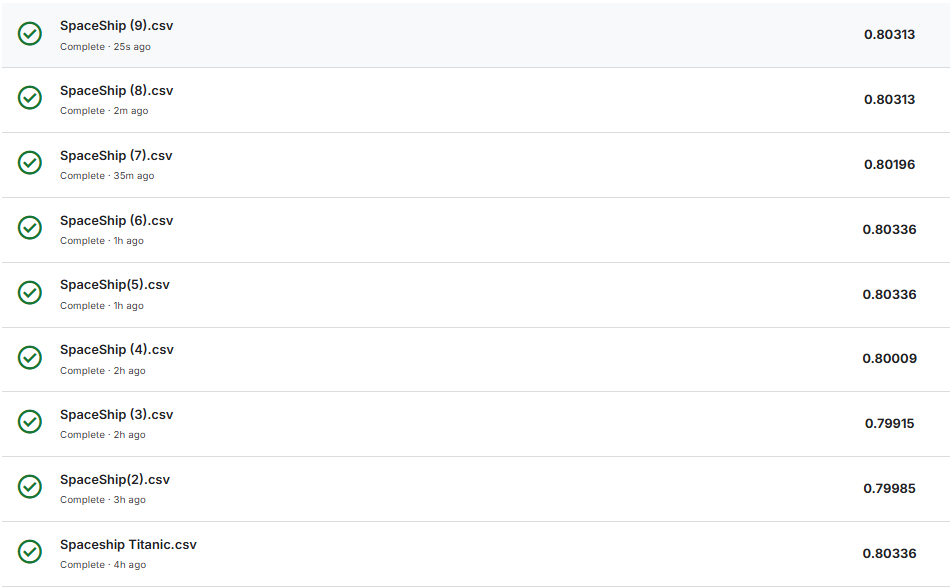